## Autoencoder on initial scRNA-seq data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import os
import glob
import functools

import torch 
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.data import random_split

import ray
from ray import tune
from ray.tune import Checkpoint
from ray.tune.schedulers import ASHAScheduler

# Set seed
torch.manual_seed(111)
np.random.seed(111)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-22 22:03:31,632	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-04-22 22:03:33,137	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Using device: cpu


We begin by loading the scRNA-seq tsv files as dataframes.

In [3]:
# Single-cell path
sc_path = "C:/Users/eddyk/OneDrive/Documents/vanopijnen_lab/scRNA-seq/"

# List files, obtain paths, then read as dfs
sc_files     = os.listdir(sc_path)
sc_filenames = ["".join([sc_path, "/" , tsv]) for tsv in sc_files]
sc_dfs       = [pd.read_table(tsv, sep = "\t", index_col = 0) for tsv in sc_filenames] # tsv

In [4]:
sc_filenames

['C:/Users/eddyk/OneDrive/Documents/vanopijnen_lab/scRNA-seq//wt_Cef1h.gene_cell_matrix.tsv.gz',
 'C:/Users/eddyk/OneDrive/Documents/vanopijnen_lab/scRNA-seq//wt_Cef2h.gene_cell_matrix.tsv.gz',
 'C:/Users/eddyk/OneDrive/Documents/vanopijnen_lab/scRNA-seq//wt_Cef4h.gene_cell_matrix.tsv.gz',
 'C:/Users/eddyk/OneDrive/Documents/vanopijnen_lab/scRNA-seq//wt_NDCtzero.gene_cell_matrix.tsv.gz']

We then concatenate everything into a single dataframe, then convert to torch tensor for training.

In [5]:
# Concatenate all dataframes
sc_data = pd.concat(sc_dfs, axis = 1, join = "outer").T

# Replace NaNs with 0
sc_data.fillna(0, inplace = True)

# Check dims and other stats*
print(f"Data dims : {sc_data.shape}")
print(f"# Cells   : {sc_data.shape[0]}")
print(f"# Genes   : {sc_data.shape[1]}")

Data dims : (40000, 2007)
# Cells   : 40000
# Genes   : 2007


Convert stuff to TPMs, because this is the input our CFU regressor uses.

In [ ]:
# How to convert stufscdf to TPM values?

Train/test split?

In [6]:
import sklearn
from sklearn.model_selection import StratifiedKFold

# Get associated labels
condition_labels = np.array(["CEF1hr"]*10000 + ["CEF2hr"]*10000 + ["CEF4hr"]*10000 + ["NDC0hr"]*10000)

# Define label to idx
cond_to_idx = {"CEF1hr": 0, "CEF2hr": 1, "CEF4hr": 2, "NDC0hr": 3}
idx_to_cond = {0: "CEF1hr", 1: "CEF2hr", 2: "CEF4hr", 3: "NDC0hr"}

# Convert condition labels to numbers
condition_idx = np.array([cond_to_idx[cond] for cond in condition_labels])

# Generate splitter object (no shuffle necessary since shuffle will be done in training)
splitter = StratifiedKFold(n_splits = 5) # 80/20 split 

# Generate split indices
train_index, test_index = next(splitter.split(sc_data, condition_idx))

# Split data
X_train = torch.tensor(sc_data.iloc[train_index].to_numpy())
X_test  = torch.tensor(sc_data.iloc[test_index].to_numpy())

# Keep condition labels in order
label_train = condition_idx[train_index]
label_test  = condition_idx[test_index]

# Examine class distribution 
train_results = [int(x) for x in np.unique_counts(condition_idx[train_index])[1]]
test_results  = [int(x) for x in np.unique_counts(condition_idx[test_index])[1]]

# Print
# Print samples
print(f"Number of training examples : {len(train_index)} ({list(train_results)})")
print(f"Number of test examples     : {len(test_index)}  ({list(test_results)})")

Number of training examples : 32000 ([8000, 8000, 8000, 8000])
Number of test examples     : 8000  ([2000, 2000, 2000, 2000])


Let's build a simple autoencoder with 2 hidden layers and RELU activation all around.

In [7]:
class simpleAE(nn.Module):
    # Simple AE with 2 hidden layers
    def __init__(self, input_dim, h1, h2, latent_dim):
        super().__init__()
        # Encoder layers
        self.enc_fc1    = nn.Linear(input_dim, h1)
        self.enc_fc2    = nn.Linear(h1, h2)
        self.enc_latent = nn.Linear(h2, latent_dim)
        # Decoder layers
        self.dec_fc1    = nn.Linear(latent_dim, h2)
        self.dec_fc2    = nn.Linear(h2, h1)
        self.dec_out    = nn.Linear(h1, input_dim)

    def encode(self, x):
        # Relu activation functions
        h = F.relu(self.enc_fc1(x))
        h = F.relu(self.enc_fc2(h))
        z = self.enc_latent(h)
        return z

    def decode(self, z):
        # Relu activation functions
        h    = F.relu(self.dec_fc1(z))
        h    = F.relu(self.dec_fc2(h))
        xhat = self.dec_out(h)
        return xhat
    
    def forward(self, x):
        z    = self.encode(x)
        xhat = self.decode(z)
        return xhat, z

In [11]:
# Store the number of input dimensions
num_genes = sc_data.shape[1]

Now, we let's define a training loop for hyperparameter tuning.

Let's define a training function that can be used raytune. Right now, we're not splitting into train and test and simply looking at how well the autoencoder is able to operate on the entire dataset. We can crack open the latent representation afterward to see if something meaning full is being captured.

Rewrite below to include the test set loop

In [ ]:
from ray import tune
from ray.tune.schedulers import ASHAScheduler

# Wrap training function in a function that is callable by ray tune
def train_ae_tune(config, X_train, X_test, batch_size, epochs):

    # Define them model
    ae = simpleAE(input_dim = num_genes,
                  h1 = config["h1"],
                  h2 = config["h2"],
                  latent_dim = config["latent_dim"]
                  )
    ae.to(device)
    
    # Define dataset and batches
    train_data = TensorDataset(X_train)
    test_data  = TensorDataset(X_test)

    train_loader  = DataLoader(train_data, batch_size = batch_size, shuffle = True)
    test_loader   = DataLoader(test_data, batch_size = batch_size, shuffle = True)
  
    # Adam optimizer with specified LR
    optim   = torch.optim.Adam(ae.parameters(), lr = config["lr"])

    # List to store loss over time
    train_losses  = []
    test_losses   = []

    for epoch in range(epochs):

        # TRAIN LOSS
        epoch_train_loss = 0.0

        # Batch (each is a tuple (x,) since we have no labels y)
        for batch_tuple in train_loader:

            # Single batch
            (xb,) = batch_tuple
            xb = xb.to(device).float()

            # Generate predicted x
            xhat, _ = ae(xb)

            # Calculate loss
            loss = F.mse_loss(xhat, xb)

            # Clear gradient, backprop, update parmaeters
            optim.zero_grad(); loss.backward(); optim.step()

            # Total loss = average batch loss * batch size
            epoch_train_loss += loss.item() * xb.size(0)

        # Compute average 
        train_losses.append(epoch_train_loss / len(X_train))

        # TEST LOSS
        epoch_test_loss = 0.0
        for batch_tuple in test_loader:
            
            with torch.no_grad():

                # Single batch
                (xb,) = batch_tuple
                xb = xb.to(device).float()

                # Generate predictions and calcualte MSE
                optim.zero_grad()

                # Generate predicted x
                xhat, _ = ae(xb)

                # Calculate loss
                loss = F.mse_loss(xhat, xb)

                # Total loss = average batch loss * batch size
                epoch_test_loss += loss.item() * xb.size(0)

        # Compute average
        test_losses.append(epoch_test_loss / len(X_test))

        # Return loss every 10 
        if (epoch + 1) % 10 == 0:
            print(f"epoch {epoch+1:3d} : Train MSE = {train_losses[-1]:.4f}, Test MSE = {test_losses[-1]:.4f}")

        # Since unsupervised, report the last loss after training
        tune.report({"test_mse": test_losses[-1]})
    
    print("Training done!")

Initialize search space

In [22]:
# Set search space
config = {
    "h1": tune.grid_search([2 ** i for i in range(8, 9)]),
    "h2": tune.grid_search([2 ** i for i in range(6, 8)]),
    "latent_dim": tune.grid_search([2 ** i for i in range(3, 5)]),
    "lr": tune.loguniform(1e-4, 1e-1),
}

# Assign scheduler
scheduler = ASHAScheduler(
    metric ="test_mse",
    mode ="min",
    max_t = 120, # no more than 120 epochs
    grace_period=1,
    reduction_factor=2
)

# Set tunable object
trainable = tune.with_parameters(
    train_ae_tune,
    X_train = X_train,
    X_test = X_test,
    batch_size = 64,
    epochs = 100
)

# Run 
tune_result = tune.run(
    trainable,
    resources_per_trial={"cpu": 2},
    config=config,
    num_samples = 3,
    scheduler=scheduler
)

2026-04-23 00:04:45,230	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949


Trial name,test_mse
train_ae_tune_90297_00000,2.30933
train_ae_tune_90297_00001,3.10321
train_ae_tune_90297_00002,2.21048
train_ae_tune_90297_00003,3.43178
train_ae_tune_90297_00004,79.9617
train_ae_tune_90297_00005,4317.44
train_ae_tune_90297_00006,26.8492
train_ae_tune_90297_00007,5.08282
train_ae_tune_90297_00008,1.21273e+07
train_ae_tune_90297_00009,2.32194


(raylet) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(raylet) I0000 00:00:1776917150.128465   18548 chttp2_transport.cc:1182] ipv4:127.0.0.1:59598: Got goaway [2] err=UNAVAILABLE:GOAWAY received; Error code: 2; Debug Text: Cancelling all calls {grpc_status:14, http2_error:2, created_time:"2026-04-23T04:05:50.1281693+00:00"}


(train_ae_tune pid=29160) epoch  10 : Train MSE = 2.0269, Test MSE = 0.0273
(train_ae_tune pid=9192) epoch  10 : Train MSE = 1.7990, Test MSE = 0.0265
(train_ae_tune pid=29160) epoch  20 : Train MSE = 2.2000, Test MSE = 0.0272
(train_ae_tune pid=9192) epoch  20 : Train MSE = 1.7787, Test MSE = 0.0262
(train_ae_tune pid=29160) epoch  30 : Train MSE = 2.1670, Test MSE = 0.0266
(train_ae_tune pid=29160) epoch  40 : Train MSE = 2.1247, Test MSE = 0.0266
(train_ae_tune pid=9192) epoch  30 : Train MSE = 1.8399, Test MSE = 0.0259
(train_ae_tune pid=29160) epoch  50 : Train MSE = 2.1233, Test MSE = 0.0265
(train_ae_tune pid=9192) epoch  40 : Train MSE = 1.9621, Test MSE = 0.0258
(train_ae_tune pid=29160) epoch  60 : Train MSE = 2.1211, Test MSE = 0.0264
(train_ae_tune pid=9192) epoch  50 : Train MSE = 2.0747, Test MSE = 0.0257
(train_ae_tune pid=29160) epoch  70 : Train MSE = 2.1680, Test MSE = 0.0263
(train_ae_tune pid=9192) epoch  60 : Train MSE = 2.2019, Test MSE = 0.0255
(train_ae_tune pid

2026-04-23 00:26:56,875	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to 'C:/Users/eddyk/ray_results/train_ae_tune_2026-04-23_00-04-45' in 0.0399s.
2026-04-23 00:26:56,886	INFO tune.py:1041 -- Total run time: 1331.66 seconds (1331.50 seconds for the tuning loop).


(train_ae_tune pid=29160) epoch 100 : Train MSE = 2.3093, Test MSE = 0.0261
(train_ae_tune pid=29160) Training done!


In [23]:
print("Best config: ", tune_result.get_best_config(metric="test_mse", mode="min"))

Best config:  {'h1': 256, 'h2': 64, 'latent_dim': 16, 'lr': 0.00285173327081303}


In [29]:
tune_result.get_best_trial

<bound method ExperimentAnalysis.get_best_trial of <ray.tune.analysis.experiment_analysis.ExperimentAnalysis object at 0x000002DE207E7390>>

Retrain model using optimal parameters

In [ ]:
def train_ae(model, X_train, X_test, epochs, batch_size = 64, lr):

    # Define dataset and batches
    train_data = TensorDataset(X_train)
    test_data  = TensorDataset(X_test)

    train_loader  = DataLoader(train_data, batch_size = batch_size, shuffle = True)
    test_loader   = DataLoader(test_data, batch_size = batch_size, shuffle = False)

    # Adam optimizer with specified LR
    optim   = torch.optim.Adam(model.parameters(), lr=lr)

    # List to store loss over time
    train_losses  = []
    test_losses   = []

    # Epochs
    for epoch in range(epochs):

        # TRAIN LOSS
        epoch_train_loss = 0.0

        # Batch (each is a tuple (x,) since we have no labels y)
        for batch_tuple in train_loader:

            # Single batch
            (xb,) = batch_tuple
            xb = xb.to(device).float()

            # Generate predicted x
            xhat, _ = model(xb)

            # Calculate loss
            loss = F.mse_loss(xhat, xb)

            # Clear gradient, backprop, update parmaeters
            optim.zero_grad(); loss.backward(); optim.step()

            # Total loss = average batch loss * batch size
            epoch_train_loss += loss.item() * xb.size(0)

        # Compute average 
        train_losses.append(epoch_train_loss / len(X_train))

        # TEST LOSS
        epoch_test_loss = 0.0
        for batch_tuple in test_loader:
            
            with torch.no_grad():

                # Single batch
                (xb,) = batch_tuple
                xb = xb.to(device).float()

                # Generate predictions and calcualte MSE
                optim.zero_grad()

                # Generate predicted x
                xhat, _ = model(xb)

                # Calculate loss
                loss = F.mse_loss(xhat, xb)

                # Total loss = average batch loss * batch size
                epoch_test_loss += loss.item() * xb.size(0)

        # Compute average
        test_losses.append(epoch_test_loss / len(X_test))

        # Return loss every 10 
        if (epoch + 1) % 10 == 0:
            print(f"epoch {epoch+1:3d}: train MSE = {train_losses[-1]:.4f}, test MSE = {test_losses[-1]:.4f}")

    return train_losses, test_losses

Train model with optimal parameters.

In [31]:
# Train the autoencoder
print("Training standard autoencoder...")

# Model
ae = simpleAE(input_dim = num_genes, 
              h1 = 246, 
              h2 = 64, 
              latent_dim = 16    # Play with latent dimension*
              ).to(device)
train_loss, test_loss = train_ae(ae, X_train = X_train, X_test = X_test, epochs = 70, lr = 0.00285173327081303)

Training standard autoencoder...
epoch  10: train MSE = 0.0272, test MSE = 2.2763
epoch  20: train MSE = 0.0268, test MSE = 3.2200
epoch  30: train MSE = 0.0266, test MSE = 4.3679
epoch  40: train MSE = 0.0265, test MSE = 5.3758
epoch  50: train MSE = 0.0265, test MSE = 6.6333
epoch  60: train MSE = 0.0264, test MSE = 4.1660
epoch  70: train MSE = 0.0277, test MSE = 8.5088


Plot loss over time.

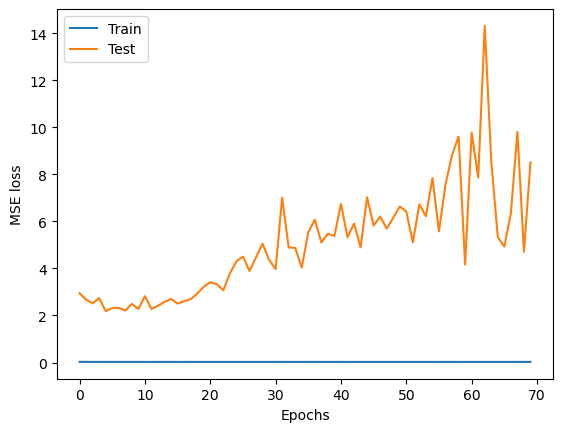

In [33]:
plt.plot(train_loss, label = "Train")
plt.plot(test_loss, label = "Test")
plt.xlabel("Epochs")
plt.ylabel("MSE loss")
plt.legend()

Observe latent space embeddings

In [ ]:
# Extract latent space by using encoder block
ae.eval()
with torch.no_grad():
    z_train = ae.encode(X_train.float().to(device))
    z_test  = ae.encode(X_test.float().to(device))

from sklearn.preprocessing import StandardScaler

# Run UMAP to visualize latent space embeddings
scaled_z_train = StandardScaler().fit_transform(z_train)
scaled_z_test  = StandardScaler().fit_transform(z_test)

# PCA object
from sklearn.decomposition import PCA
pca1 = PCA(n_components = 2)

# Fit PCA and store results as df
pc_result = pca1.fit_transform(z_train)
pc_df     = pca1.
embed_train = reducer.fit_transform(scaled_z_train)

# 
plt.scatter(
    embed_train[:,0],
    embed_train[:,1]
)